# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [2]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

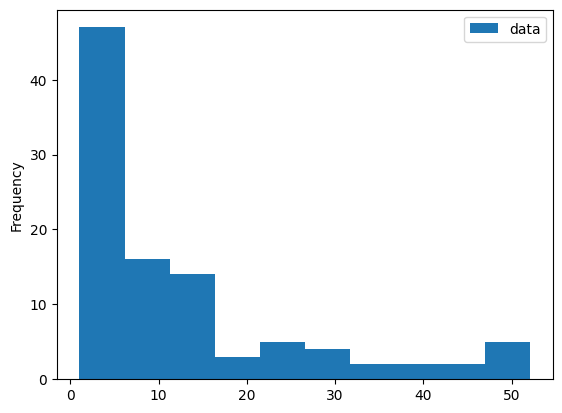

In [3]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

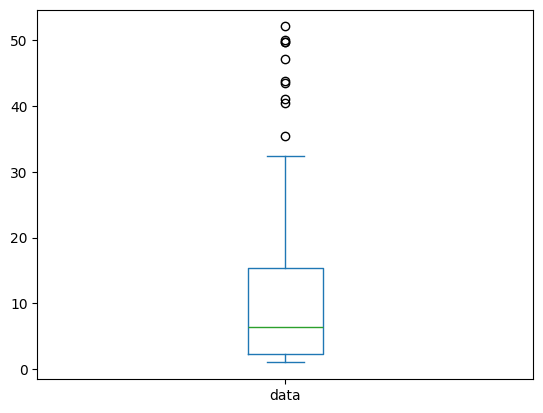

In [4]:
df.plot.box()

### **Histogram**
**pros**
- Helps visualize the shape of the data. Helps figure out if the data is bell shaped, skewed, or has two peaks. 
- Helps easily identiry where a majority of the data congregates.
- Shows how much of the data falls into each bin. Helps in understanding the density of the data. 

**cons**
- the visual changes drastically based on the bin size. Too few bins can hide important information, too many can look noisy. 
- hard to see values like median or quartiles. 

### **Box Plot**
**pros**
- Easily identify outliers. They are identified as dots, so it makes it easy to track.
- Can easily see the median, and the spread of the data without manual calculations. 
- Work with very small datasets. 

**cons**
- Can hide distribution differences. 
- Less intuitive. Unless you know how to read a box plot, it is hard to understand what is going on and what each feature means. 

I would choose a histogram. I would modify the histogram so that is has a descriptive x and y axis label, and a descriptive title. I would add lines seperating each bin. I would get rid of the legend since it is not providing any information. 

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [5]:
# Reading in the data
# Reading data from a CSV file
google_data = pd.read_csv('./datasets/GoogleAds_DataAnalytics_Sales_Uncleaned.csv')
google_data.info()
google_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ad_ID            2600 non-null   object 
 1   Campaign_Name    2600 non-null   object 
 2   Clicks           2488 non-null   float64
 3   Impressions      2546 non-null   float64
 4   Cost             2503 non-null   object 
 5   Leads            2552 non-null   float64
 6   Conversions      2526 non-null   float64
 7   Conversion Rate  1974 non-null   float64
 8   Sale_Amount      2461 non-null   object 
 9   Ad_Date          2600 non-null   object 
 10  Location         2600 non-null   object 
 11  Device           2600 non-null   object 
 12  Keyword          2600 non-null   object 
dtypes: float64(5), object(8)
memory usage: 264.2+ KB


,Clicks,Impressions,Leads,Conversions,Conversion Rate
count,2488.000000,2546.000000,2552.000000,2526.000000,1974.000000
mean,138.956994,4523.280833,20.003918,6.519002,0.048979
std,34.619376,869.927913,6.032317,2.272573,0.019987
min,80.000000,3000.000000,10.000000,3.000000,0.015000
25%,110.000000,3764.000000,15.000000,5.000000,0.035000
50%,139.000000,4518.500000,20.000000,7.000000,0.046000
75%,169.000000,5279.500000,25.000000,9.000000,0.058000
max,199.000000,5999.000000,30.000000,10.000000,0.123000


In [6]:
# Fix conversion rate issues using a copy of the data
# We create google_clean to preserve the raw source of truth
google_clean = google_data.copy()

# Verify conversion rates on the clean copy
google_clean['Clicks'] = pd.to_numeric(google_clean['Clicks'], errors='coerce')
google_clean['Conversions'] = pd.to_numeric(google_clean['Conversions'], errors='coerce')
google_clean['Conversion Rate'] = pd.to_numeric(google_clean['Conversion Rate'], errors='coerce')

# Step 1: Calculate Conversion Rate (rounded to 3 decimals)
calculated_rate = (google_clean['Conversions'] / google_clean['Clicks']).round(3)

# Step 2: Flag mismatches
mismatch_flag = (google_clean['Conversion Rate'] != 0) & \
                (~google_clean['Conversion Rate'].isna()) & \
                (google_clean['Conversion Rate'].round(3) != calculated_rate)

# Step 3: Extract bad rows with correct Conversion Rate for reference
bad_rows = google_clean[mismatch_flag].copy()
bad_rows['Calculated Conversion Rate'] = calculated_rate[mismatch_flag]

# Fixing the mismatches in the new DataFrame (leaving google_data untouched)
google_clean.loc[mismatch_flag, 'Conversion Rate'] = calculated_rate[mismatch_flag]

In [7]:
# Checking for inconsistencies in campign names
google_clean['Campaign_Name'] = google_clean['Campaign_Name'].astype(str)
unique_campaigns = google_clean['Campaign_Name'].nunique()
print("Total unique Campaign Names:", unique_campaigns)
google_data_incorrect_campigns = google_clean['Campaign_Name'] != "Data Analytics Course"
if google_data_incorrect_campigns.sum() > 0:
    print("Inconsistent Campaign Names found:", google_data_incorrect_campigns.sum())
    print(google_clean[google_data_incorrect_campigns]['Campaign_Name'].unique())
else:
    print("All Campaign Names are consistent.")

google_clean.loc[google_clean['Campaign_Name'] != "Data Analytics Course", 'Campaign_Name'] = "Data Analytics Course"

Total unique Campaign Names: 4
Inconsistent Campaign Names found: 2600
['DataAnalyticsCourse' 'Data Anlytics Corse' 'Data Analytcis Course'
 'Data Analytics Corse']


In [8]:
# Verifying the fix
unique_campaigns_after_fix = google_clean['Campaign_Name'].nunique()
print("Total unique Campaign Names after fix:", unique_campaigns_after_fix)

Total unique Campaign Names after fix: 1


In [9]:
# Get missing values
na_columns = google_clean.columns[google_clean.isna().any()].tolist()
for column in na_columns:
    na_count = google_clean[column].isna().sum()
    print(f"Column '{column}' has {na_count} missing values.")

Column 'Clicks' has 112 missing values.
Column 'Impressions' has 54 missing values.
Column 'Cost' has 97 missing values.
Column 'Leads' has 48 missing values.
Column 'Conversions' has 74 missing values.
Column 'Conversion Rate' has 656 missing values.
Column 'Sale_Amount' has 139 missing values.


In [10]:
# Fix missing numeric values by filling with median
google_imputed = google_clean.copy()
numeric_columns = google_clean.select_dtypes(include=[np.number]).columns
for column in numeric_columns:
    if google_clean[column].isna().sum() > 0:
        median_value = google_clean[column].median()
        google_imputed[column] = google_imputed[column].fillna(median_value)
        print(f"Filled missing values in '{column}' with median value: {median_value}")


Filled missing values in 'Clicks' with median value: 139.0
Filled missing values in 'Impressions' with median value: 4518.5
Filled missing values in 'Leads' with median value: 20.0
Filled missing values in 'Conversions' with median value: 7.0
Filled missing values in 'Conversion Rate' with median value: 0.046


In [11]:
# Verifying the fix to the numeric columns
na_columns = google_imputed.columns[google_clean.isna().any()].tolist()
for column in na_columns:
    na_count = google_clean[column].isna().sum()
    print(f"Column '{column}' has {na_count} missing values.")

Column 'Clicks' has 112 missing values.
Column 'Impressions' has 54 missing values.
Column 'Cost' has 97 missing values.
Column 'Leads' has 48 missing values.
Column 'Conversions' has 74 missing values.
Column 'Conversion Rate' has 656 missing values.
Column 'Sale_Amount' has 139 missing values.


In [12]:
# Change cost from dollar to numeric
google_cost_fix = google_imputed.copy()
google_cost_fix['Cost'] = google_cost_fix['Cost'].replace(r'[\$,]', '', regex=True)
google_cost_fix['Cost'] = pd.to_numeric(google_cost_fix['Cost'], errors='coerce')

# Fixing the cost column by setting na to median
if google_cost_fix['Cost'].isna().sum() > 0:
    median_cost = google_cost_fix['Cost'].median()
    google_cost_fix['Cost'] = google_cost_fix['Cost'].fillna(median_cost)
    print(f"Filled missing values in 'Cost' with median value: {median_cost}")


Filled missing values in 'Cost' with median value: 215.57


In [13]:
# Change sale amount from dollar to numeric
google_cost_fix['Sale_Amount'] = google_cost_fix['Sale_Amount'].replace(r'[\$,]', '', regex=True)
google_cost_fix['Sale_Amount'] = pd.to_numeric(google_cost_fix['Sale_Amount'], errors='coerce')
# Fixing the sale amount column by setting na to median
if google_cost_fix['Sale_Amount'].isna().sum() > 0:
    median_sale_amount = google_cost_fix['Sale_Amount'].median()
    google_cost_fix['Sale_Amount'] = google_cost_fix['Sale_Amount'].fillna(median_sale_amount)
    print(f"Filled missing values in 'Sale Amount' with median value: {median_sale_amount}")

Filled missing values in 'Sale Amount' with median value: 1505.0


In [14]:
# Get unique values in location
unique_locations = google_cost_fix['Location'].nunique()
print("Total unique Locations:", unique_locations)

# it is all one location so just drop the column
google_location_fix = google_cost_fix.drop(columns=['Location'])

# Get unique values in Device
unique_devices = google_location_fix['Device'].nunique()
# Get unique values in Device
print("Unique Devices:", google_location_fix['Device'].unique())
# Make value consistent by capitalizing all entries
google_location_fix['Device'] = google_location_fix['Device'].str.capitalize()
# Get unique values in Device after fix
unique_devices_after_fix = google_location_fix['Device'].nunique()
print("Unique Devices after fix:", google_location_fix['Device'].unique())

# Get unique Keyword values
unique_keywords = google_location_fix['Keyword'].nunique()
print("Unique Keywords:", google_location_fix['Keyword'].unique()) # Seems to be fine, no fix needed

# Drop date since it is one month
google_location_fix = google_location_fix.drop(columns=['Ad_Date'])
# Campeign name seems like one value, so drop the column
google_final = google_location_fix.drop(columns=['Campaign_Name'])

Total unique Locations: 4
Unique Devices: ['desktop' 'mobile' 'Desktop' 'tablet' 'MOBILE' 'TABLET' 'Tablet' 'Mobile'
 'DESKTOP']
Unique Devices after fix: ['Desktop' 'Mobile' 'Tablet']
Unique Keywords: ['learn data analytics' 'data analytics course' 'data analitics online'
 'data anaytics training' 'online data analytic' 'analytics for data']


In [15]:
# Verify the new data with all the fixes
print("Final data info:")
google_final.info()
print("\nFinal data description:")
google_final.describe()

Final data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ad_ID            2600 non-null   object 
 1   Clicks           2600 non-null   float64
 2   Impressions      2600 non-null   float64
 3   Cost             2600 non-null   float64
 4   Leads            2600 non-null   float64
 5   Conversions      2600 non-null   float64
 6   Conversion Rate  2600 non-null   float64
 7   Sale_Amount      2600 non-null   float64
 8   Device           2600 non-null   object 
 9   Keyword          2600 non-null   object 
dtypes: float64(7), object(3)
memory usage: 203.3+ KB

Final data description:


,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount
count,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000
mean,138.958846,4523.181538,215.108508,20.003846,6.532692,0.048874,1498.987692
std,33.865228,860.843403,19.907580,5.976353,2.241415,0.019542,279.327209
min,80.000000,3000.000000,180.010000,10.000000,3.000000,0.015000,1000.000000
25%,111.000000,3778.000000,198.385000,15.000000,5.000000,0.037000,1262.000000
50%,139.000000,4518.500000,215.570000,20.000000,7.000000,0.046000,1505.000000
75%,167.000000,5268.250000,232.297500,25.000000,8.000000,0.056000,1728.000000
max,199.000000,5999.000000,249.890000,30.000000,10.000000,0.125000,2000.000000


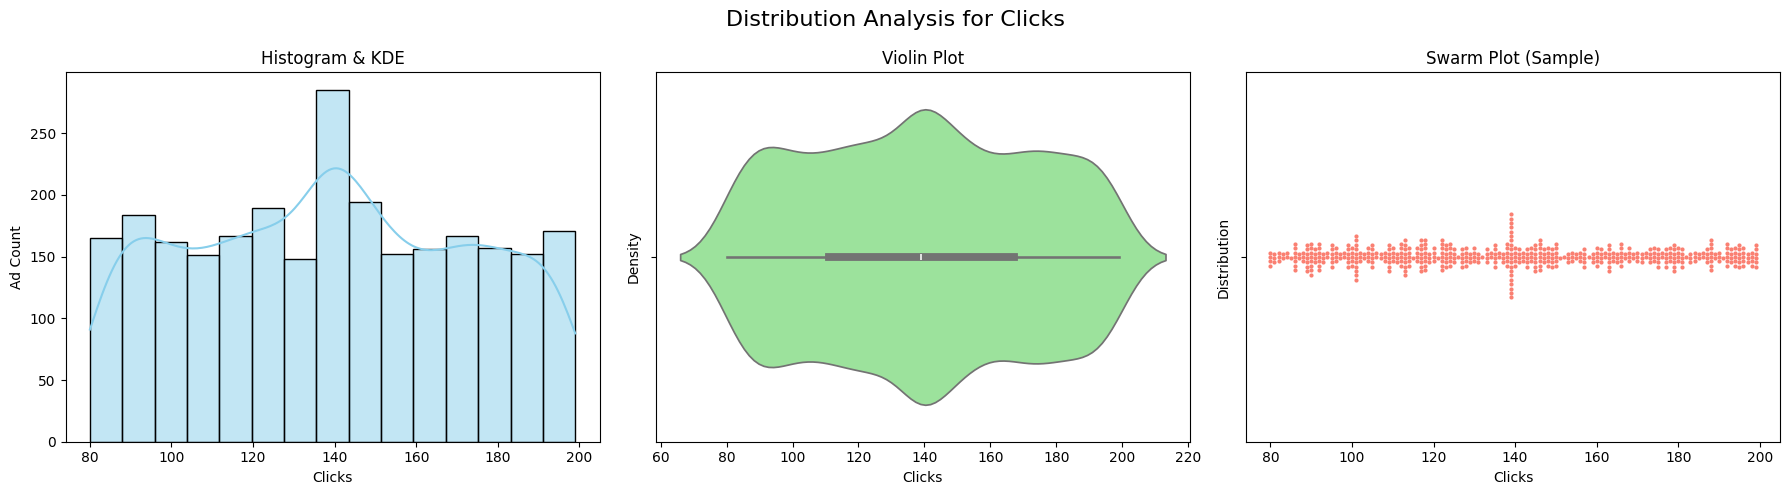

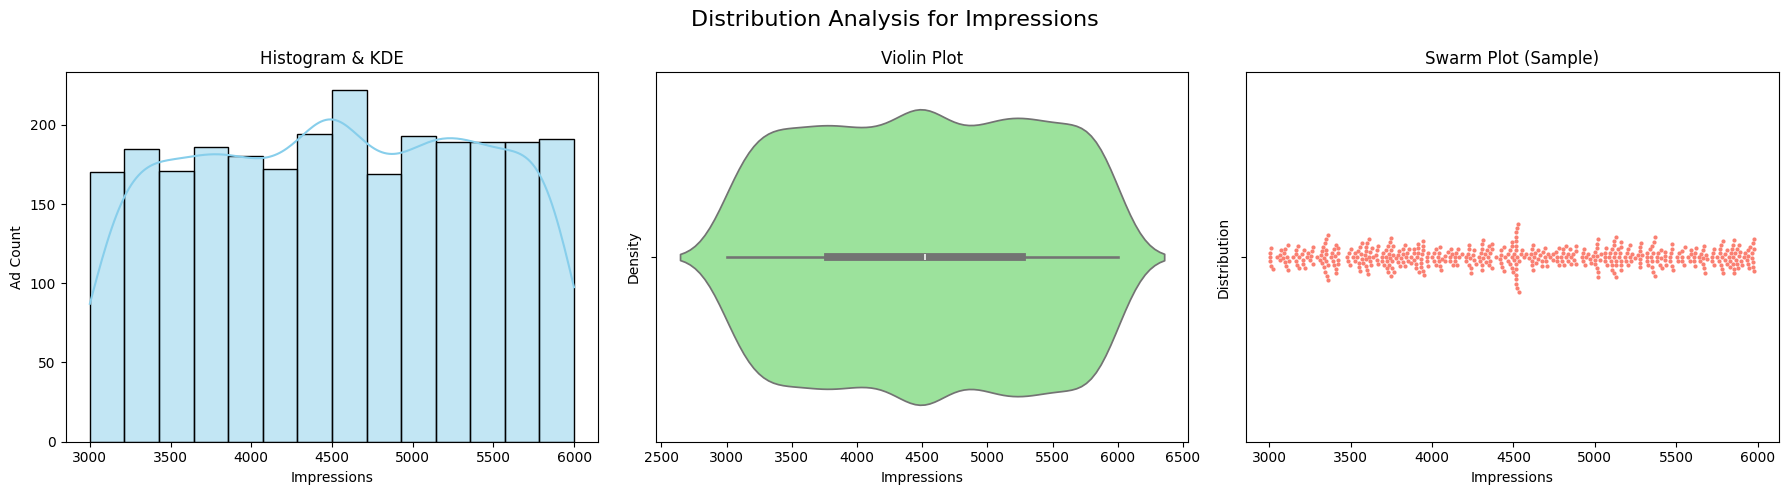

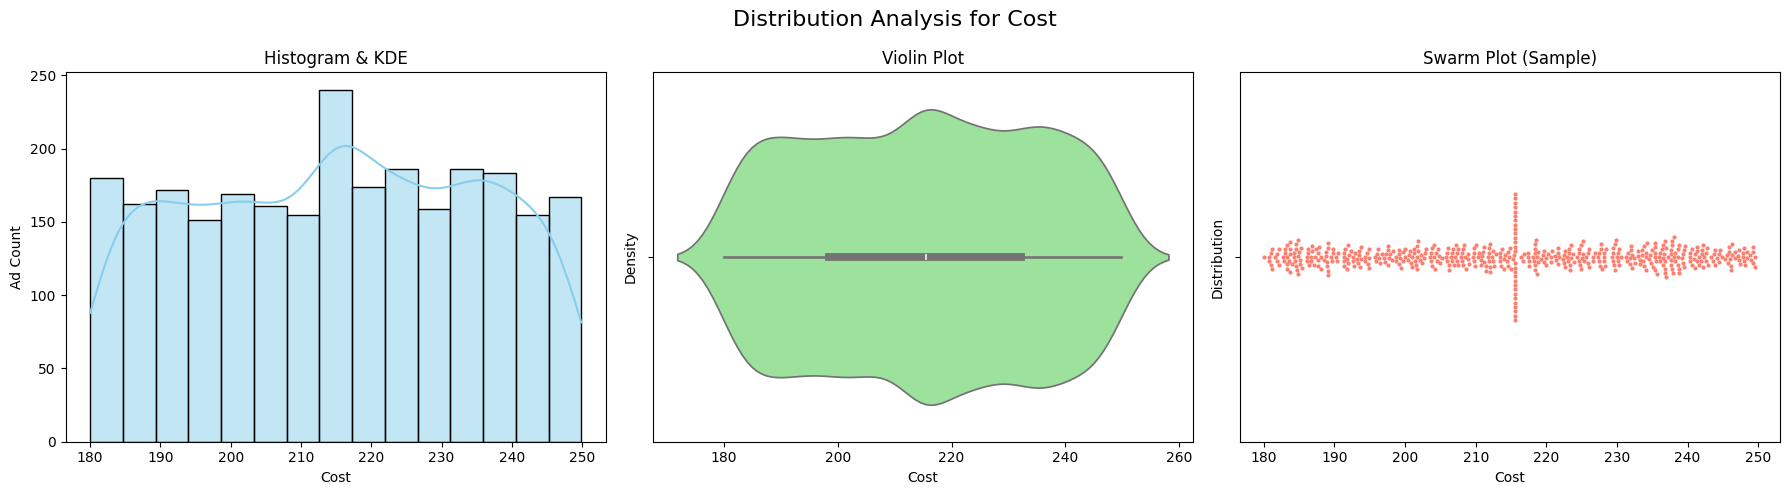

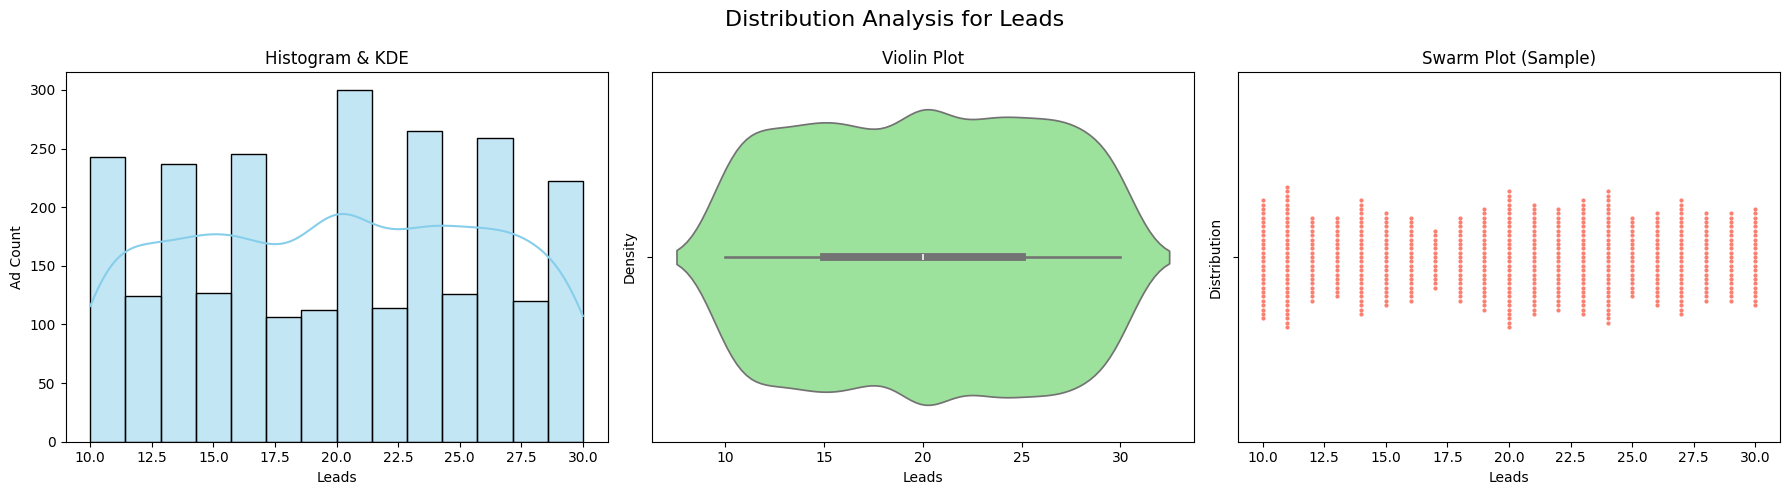

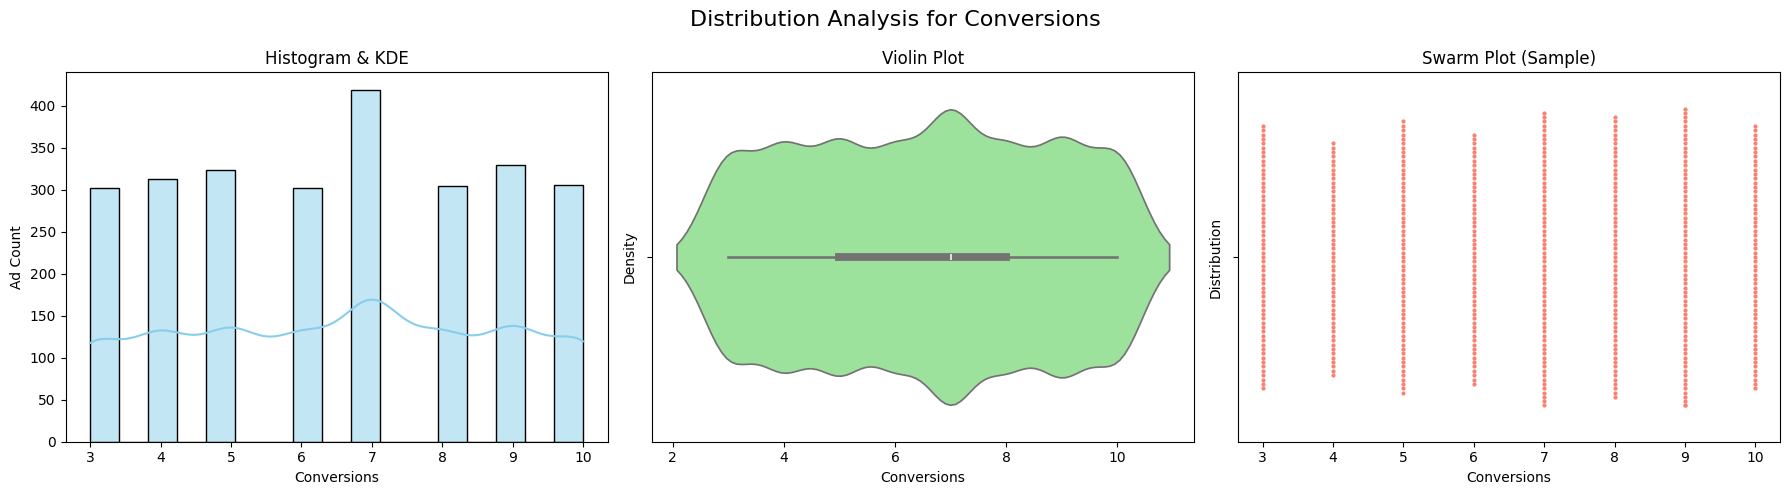

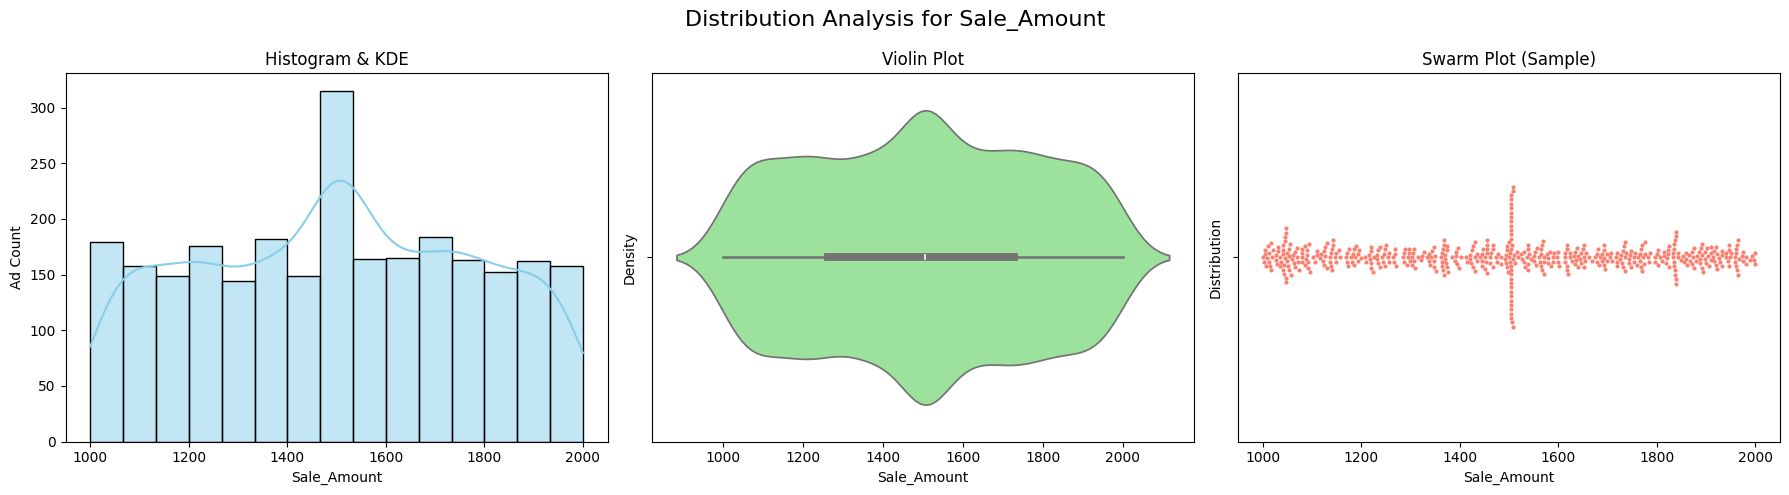

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
#turn date by day to by month
google_final_features = google_final.drop(columns=['Conversion Rate']) 

# Identify numerical features
numerical_cols = google_final_features.select_dtypes(include=['number']).columns

for col in numerical_cols:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Distribution Analysis for {col}', fontsize=16)

    # 1. Histogram
    sns.histplot(google_final[col], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title('Histogram & KDE')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Ad Count') # Correctly labeled

    # 2. Violin Plot
    sns.violinplot(x=google_final[col], ax=axes[1], color='lightgreen')
    axes[1].set_title('Violin Plot')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Density') # In violins, y-axis is usually density or width

    # 3. Swarm Plot 
    sns.swarmplot(x=google_final[col].head(500), ax=axes[2], color='salmon', size=3)
    axes[2].set_title('Swarm Plot (Sample)')
    axes[2].set_xlabel(col)
    axes[2].set_ylabel('Distribution') # Swarms spread points out to show distribution

    plt.tight_layout()
    plt.show()

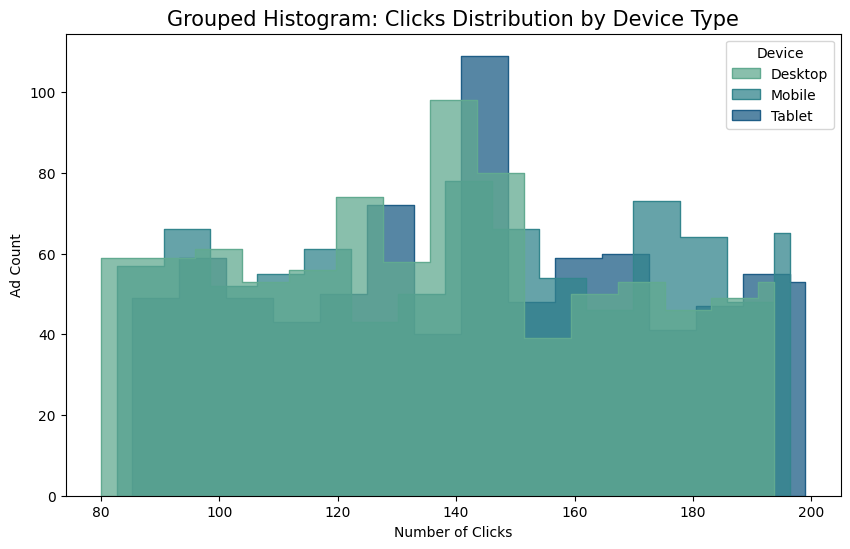

In [17]:
# Grouped Histogram: Clicks by Device
plt.figure(figsize=(10, 6))
sns.histplot(data=google_final, x='Clicks', hue='Device', kde=False, element="step", palette='crest', multiple="dodge")

plt.title('Grouped Histogram: Clicks Distribution by Device Type', fontsize=15)
plt.xlabel('Number of Clicks')
plt.ylabel('Ad Count')
plt.show()

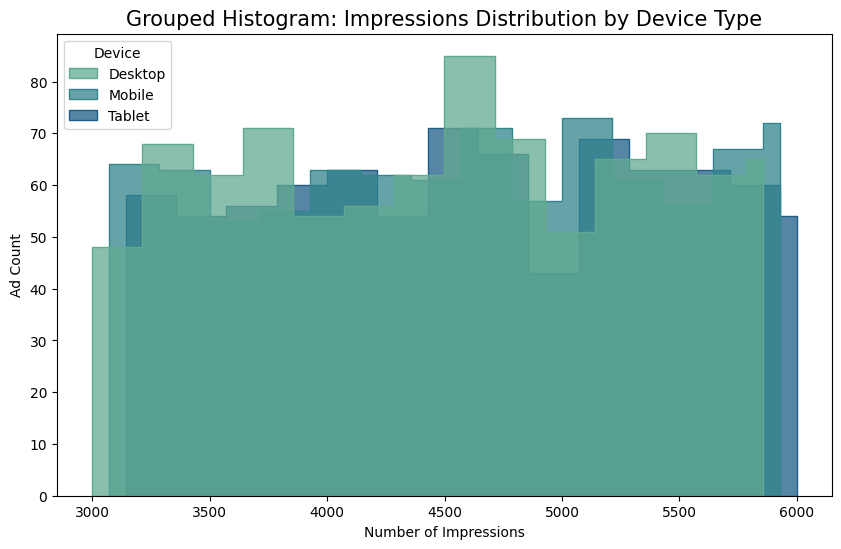

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(data=google_final, x='Impressions', hue='Device', kde=False, element="step", palette='crest', multiple="dodge")

plt.title('Grouped Histogram: Impressions Distribution by Device Type', fontsize=15)
plt.xlabel('Number of Impressions')
plt.ylabel('Ad Count')
plt.show()

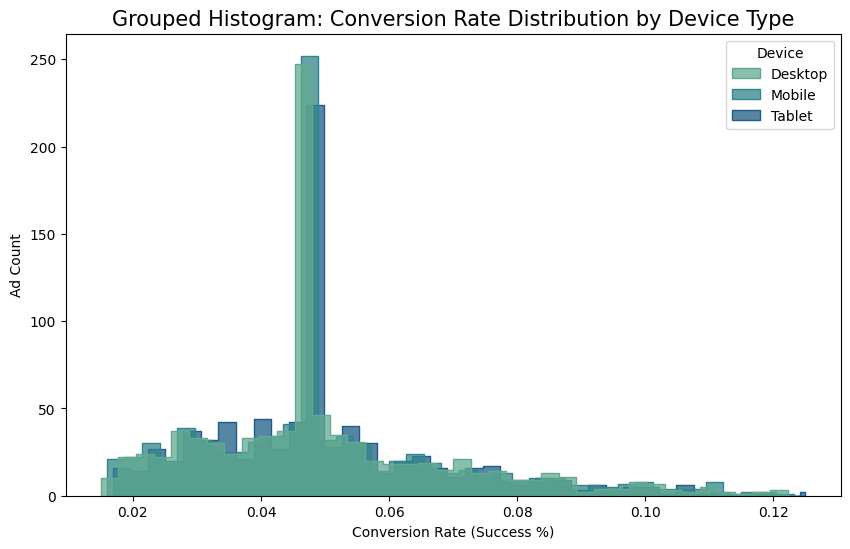

In [19]:
plt.figure(figsize=(10, 6))

# Using your requested parameters: crest palette, no KDE, and dodged bars
sns.histplot(data=google_final, 
             x='Conversion Rate', 
             hue='Device', 
             kde=False, 
             element="step", 
             palette='crest', 
             multiple="dodge")

plt.title('Grouped Histogram: Conversion Rate Distribution by Device Type', fontsize=15)
plt.xlabel('Conversion Rate (Success %)')
plt.ylabel('Ad Count')
plt.show()

In [20]:
google_final.head()

,Ad_ID,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Device,Keyword
0,A1000,104.0,4498.0,231.88,14.0,7.0,0.067,1892.0,Desktop,learn data analytics
1,A1001,173.0,5107.0,216.84,10.0,8.0,0.046,1679.0,Mobile,data analytics course
2,A1002,90.0,4544.0,203.66,26.0,9.0,0.046,1624.0,Desktop,data analitics online
3,A1003,142.0,3185.0,237.66,17.0,6.0,0.046,1225.0,Tablet,data anaytics training
4,A1004,156.0,3361.0,195.90,30.0,8.0,0.046,1091.0,Desktop,online data analytic


C:\Users\peace\AppData\Local\Temp\ipykernel_11332\1529158190.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=google_final, x=col, palette=palette, order=plot_order)


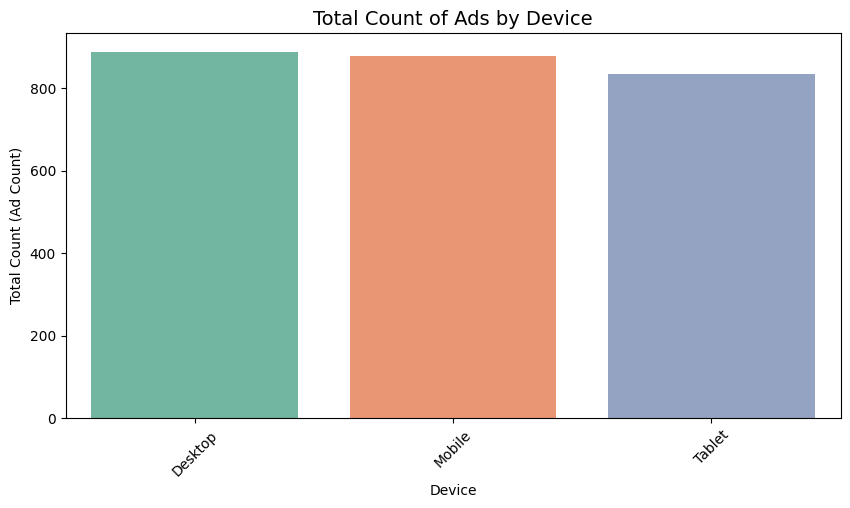

C:\Users\peace\AppData\Local\Temp\ipykernel_11332\1529158190.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=google_final, x=col, palette=palette, order=plot_order)


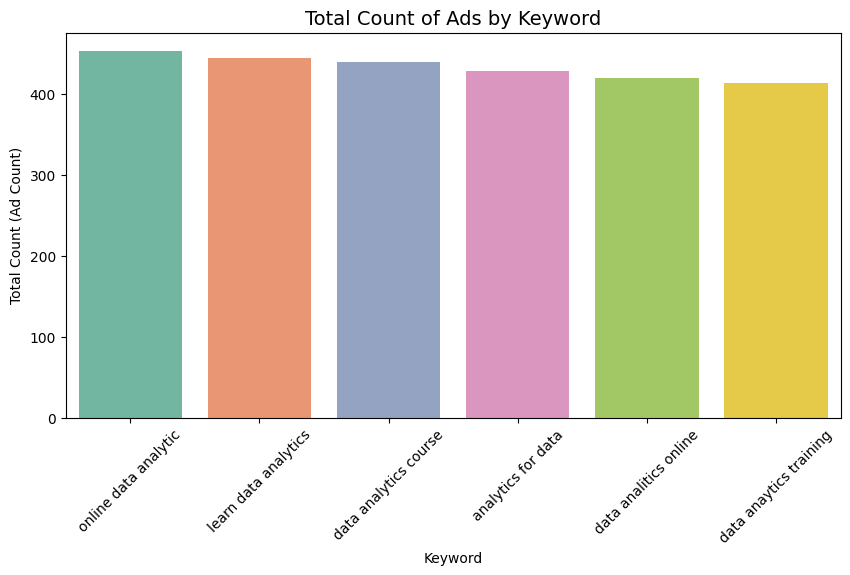

In [21]:
categorical_cols = google_final.select_dtypes(include=['object']).columns.drop(['Ad_ID'])  # Exclude the cleaned date string if not needed for plotting

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    
    # Logic: If it's the Month column, sort chronologically. 
    # Otherwise, sort by frequency (highest count first).
    if col == 'Ad_Month':
        plot_order = sorted(google_final[col].unique())
        palette = 'Blues_d' # Using a sequential blue for the timeline
    else:
        plot_order = google_final[col].value_counts().index
        palette = 'Set2'

    sns.countplot(data=google_final, x=col, palette=palette, order=plot_order)
    
    plt.title(f'Total Count of Ads by {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Total Count (Ad Count)')
    
    plt.xticks(rotation=45) 
    plt.show()

In [22]:
numeric_columns = google_final.select_dtypes(include=[np.number]).columns.tolist()

for column in numeric_columns:
    mean_value = google_final[column].mean()      
    mode_value = google_final[column].mode()[0]   
    median_value = google_final[column].median()  
    print(f"Column '{column}': Mean = {mean_value}, Mode = {mode_value}, Median = {median_value}")

Column 'Clicks': Mean = 138.95884615384617, Mode = 139.0, Median = 139.0
Column 'Impressions': Mean = 4523.181538461538, Mode = 4518.5, Median = 4518.5
Column 'Cost': Mean = 215.10850769230774, Mode = 215.57, Median = 215.57
Column 'Leads': Mean = 20.003846153846155, Mode = 20.0, Median = 20.0
Column 'Conversions': Mean = 6.532692307692308, Mode = 7.0, Median = 7.0
Column 'Conversion Rate': Mean = 0.048874230769230774, Mode = 0.046, Median = 0.046
Column 'Sale_Amount': Mean = 1498.9876923076922, Mode = 1505.0, Median = 1505.0


In [23]:
# Get outliers using z score method
from scipy import stats
z_scores = np.abs(stats.zscore(google_final[numeric_columns]))
outliers = (z_scores > 3).any(axis=1)
print(f"Number of outliers detected: {outliers.sum()}")
# Printing outliers for reference 
print("Outlier rows:")
print(google_final[outliers])


Number of outliers detected: 35
Outlier rows:
      Ad_ID  Clicks  Impressions    Cost  Leads  Conversions  Conversion Rate  \
68    A1068    84.0       4036.0  234.22   23.0         10.0            0.119   
168   A1168    86.0       5124.0  183.71   13.0         10.0            0.116   
207   A1207    90.0       5119.0  226.58   14.0         10.0            0.111   
241   A1241    82.0       5130.0  233.75   20.0          9.0            0.110   
418   A1418    81.0       3147.0  232.20   30.0          9.0            0.111   
550   A1550    84.0       4407.0  192.52   19.0         10.0            0.119   
719   A1719    86.0       5663.0  231.79   19.0         10.0            0.116   
828   A1828    85.0       4772.0  211.62   15.0         10.0            0.118   
858   A1858    91.0       5609.0  228.27   12.0         10.0            0.110   
875   A1875    82.0       4622.0  203.99   17.0          9.0            0.110   
1100  A2100    89.0       4319.0  198.79   23.0         10.0   

In [24]:
google_final.to_csv('./datasets/GoogleAds_DataAnalytics_Sales_Cleaned.csv', index=False)

For my analysis, I started by cleaning the raw data to ensure it was usable for modeling. I specifically addressed the conversion column by fixing incorrect values based on the relationship between clicks and conversions. I then filled any missing values in the numeric columns using the median, which helped eliminate null entries while keeping the central tendency intact. I also standardized spelling errors in categorical columns and adjusted data types to make them easier to work with. Finally, I dropped redundant columns like `Campaign_Name` and `Location` because they only contained a single value and wouldn't provide any useful insight for the analysis.

### Conclusions and Data Usability

Based on my analysis, the data is exactly what I expected for a standard ad campaign. It is very clean and follows logical patterns, making it highly usable for future modeling. The metrics like `Clicks`, `Impressions`, `Cost`, `Leads`, and `Sale_Amount` all show healthy variance and consistent tracking.

### Distribution Shapes and Normality

* **Overall Shape**: Most of my numeric features follow a **Normal (Gaussian)** distribution. This is clear from the bell-shaped histograms I generated earlier.
* **Skewness**: While most features are symmetrical, `Conversion Rate` is **Right-Skewed** (Positive Skew). This indicates that most ads have a typical performance, but a small group of high-performing ads pulls the tail to the right.
* **Specific Normality**: `Clicks`, `Impressions`, `Cost`, and `Leads` all have skewness values very close to zero, confirming they appear normal.

### Outliers

I detected **35 outliers** in the dataset using the 3-standard-deviation rule. These points are far from the rest of the data—for instance, some ads have conversion rates as high as 12.5% when the average is only 4.8%. While these are statistically "extreme," they represent the most successful ads.

### Grouped Analysis (Device Type)

When I looked at multiple related histograms grouped by `Device`, I found that the distribution remains relatively consistent across Desktop, Mobile, and Tablet users. This suggests that user behavior is stable across different hardware, even if the total volume of ads might vary.

### Minimum and Maximum Values

Here are the ranges I found for each major metric:

* **Clicks**: 80.0 to 199.0
* **Impressions**: 3,000.0 to 5,999.0
* **Cost**: $180.01 to $249.89
* **Leads**: 10.0 to 30.0
* **Conversion Rate**: 0.015 to 0.125
* **Sale Amount**: $1,000.0 to $2,000.0

### Effect of Bin Sizes

I noticed that bin size significantly affects the patterns shown in the histograms. Using a smaller number of bins (like 10) provides a smooth, generalized overview of the normal distribution. However, increasing the bin width (to 50) revealed more granular "peaks," suggesting the data might be clustered around certain specific values rather than being perfectly continuous.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

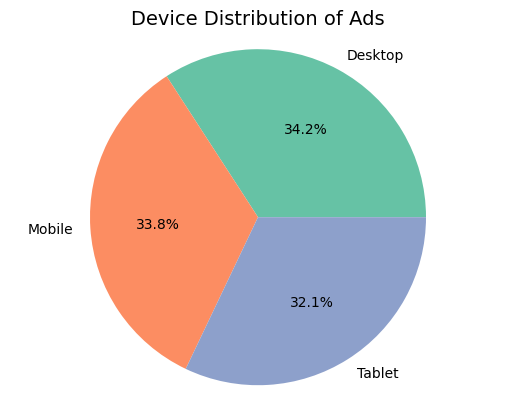

In [25]:
plt.pie(google_final['Device'].value_counts(), labels=google_final['Device'].value_counts().index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title('Device Distribution of Ads', fontsize=14)
plt.axis('equal')
plt.show()
